<a href="https://colab.research.google.com/github/ankitha-454/6thsemproject/blob/main/PCOS_Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scikit-learn pandas numpy matplotlib seaborn -q
print("Libraries installed")

Libraries installed


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pickle

print("All libraries loaded")

All libraries loaded


In [ ]:
np.random.seed(42)

n=5000

data={
 "age":np.random.randint(18,45,n),
 "bmi":np.random.uniform(18,35,n),
 "cycle":np.random.randint(21,50,n),
 "lh":np.random.uniform(2,20,n),
 "fsh":np.random.uniform(2,15,n),
 "insulin":np.random.uniform(5,30,n),
 "acne":np.random.randint(0,3,n),
 "hair":np.random.randint(0,3,n)
}

df=pd.DataFrame(data)

df["pcos"]=(
 (df["bmi"]>27).astype(int)+
 (df["cycle"]>35).astype(int)+
 ((df["lh"]/df["fsh"])>2).astype(int)
)

df["pcos"]=(df["pcos"]>1).astype(int)

df.head()

,age,bmi,cycle,lh,fsh,insulin,acne,hair,pcos
0,24,26.613435,41,11.990333,3.015356,18.791168,1,1,1
1,37,24.583034,23,7.169826,14.261120,11.384934,1,0,0
2,32,33.411728,47,18.923169,3.291976,15.890495,1,0,1
3,28,18.273052,46,15.717290,13.112844,17.907900,2,0,0
4,25,31.296911,31,19.505261,2.004027,7.417996,2,0,1


In [ ]:
X=df.drop("pcos",axis=1)
y=df["pcos"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

model=RandomForestClassifier()
model.fit(X_train,y_train)

pred=model.predict(X_test)
print("Accuracy:",accuracy_score(y_test,pred))

Accuracy: 0.983


In [ ]:
with open("model.pkl","wb") as f:
    pickle.dump(model,f)

print("Model saved")

Model saved


In [ ]:
X = df.drop("pcos", axis=1)
y = df["pcos"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = RandomForestClassifier()

In [ ]:
model.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Predictions
y_pred = model.predict(X_test)

print("Predictions completed!")

Predictions completed!


In [ ]:
# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[631   1]
 [ 11 357]]


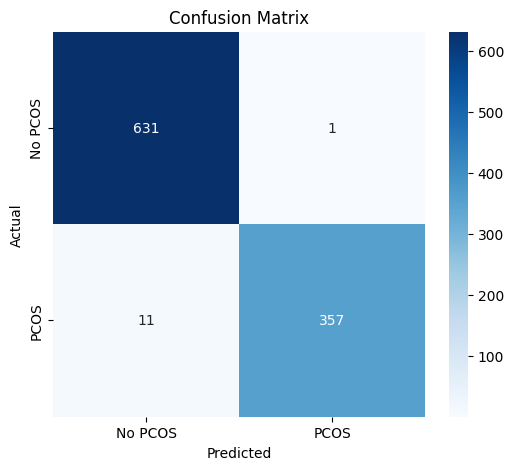

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No PCOS','PCOS'],
            yticklabels=['No PCOS','PCOS'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print("Sensitivity (Recall):", round(sensitivity,4))
print("Specificity:", round(specificity,4))

Sensitivity (Recall): 0.9701
Specificity: 0.9984
